In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [5]:
data = pd.read_csv('../../data/data.csv')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 64663 entries, 0 to 64662
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      64662 non-null  float64
 1   miktar                      52485 non-null  float64
 2   markalar                    62414 non-null  str    
 3   alerjenler                  64663 non-null  str    
 4   eser_miktarlar              64663 non-null  str    
 5   icerik_sayisi               56569 non-null  float64
 6   nutriscore_notu             64604 non-null  str    
 7   nova_grubu                  55315 non-null  float64
 8   yesil_skor_notu             48007 non-null  str    
 9   palmiye_yagi_icermez        52774 non-null  object 
 10  vejetaryen                  50318 non-null  object 
 11  vegan_durumu                56899 non-null  str    
 12  enerji_kcal                 64050 non-null  float64
 13  yag_g                       64046 non-null

In [7]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,6.466200e+04,5.248500e+04,56569.000000,55315.000000,64050.000000,64046.000000,63371.000000,63993.000000,63752.000000,45823.000000,64042.000000,64172.000000,3203.000000,18707.000000
mean,6.010123e+12,1.322393e+08,13.082908,3.101437,269.949602,14.179282,4.700736,26.647547,10.130726,3.245956,7.514401,6.748853,4.993035,14.102474
std,4.012318e+14,2.629521e+10,13.437641,1.153712,390.455067,33.355534,8.591483,29.333040,20.687990,4.977845,9.292548,1405.340677,19.851106,30.849711
min,1.526000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,-1.217330
25%,3.256226e+12,5.000000e+01,4.000000,3.000000,76.000000,1.000000,0.200000,4.000000,0.500000,0.400000,1.600000,0.030000,0.000000,0.000000
50%,4.012359e+12,2.000000e+02,10.000000,4.000000,232.000000,5.300000,1.300000,12.900000,3.200000,1.900000,5.900000,0.300000,0.000000,0.000000
75%,5.942204e+12,4.000000e+02,18.000000,4.000000,409.000000,20.100000,5.700000,52.000000,10.800000,4.400000,10.000000,0.984252,0.000000,8.437500
max,1.020304e+17,5.940568e+12,405.000000,4.000000,49328.000000,5856.650000,450.000000,1900.000000,1700.000000,375.000000,800.000000,355942.500000,100.000000,449.400000


In [8]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
29079,5.600955e+12,200.0,bio+,['Gluten'],"['Nuts', 'Soybeans']",10.0,C,4.0,A,True,True,yes,57.0,1.9,0.2,7.1,5.0,NaN,1.7,0.1000,NaN,NaN,ml,"['Plant-based foods and beverages', 'Beverages...","['Organic', 'Vegetarian', 'EU Organic', 'Non-E..."
60506,2.007364e+07,100.0,pikok,[],[],22.0,E,4.0,NaN,True,False,no,439.0,39.0,14.0,2.0,1.6,NaN,20.0,2.4575,NaN,NaN,g,['ro:Mezeluri feliate'],[]
45092,5.410106e+12,NaN,bosto,['Milk'],[],20.0,D,4.0,D,True,NaN,no,462.0,20.0,2.0,62.0,3.5,3.0,7.6,1.4450,NaN,NaN,NaN,"['Plant-based foods and beverages', 'Plant-bas...","['No gluten', 'Nutriscore', 'Nutriscore Grade C']"
8263,3.057640e+12,NaN,volvic,[],[],NaN,A,1.0,A,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0000,NaN,NaN,NaN,"['Beverages and beverages preparations', 'Beve...",[]
8466,8.410066e+12,400.0,orlando,[],[],4.0,A,3.0,NaN,True,True,yes,18.0,0.1,0.0,3.1,3.1,NaN,0.7,0.3000,NaN,NaN,g,"['Plant-based foods and beverages', 'Plant-bas...","['No gluten', 'Green Dot']"


In [9]:
data.isnull().mean() * 100

barkod                         0.001546
miktar                        18.833027
markalar                       3.478032
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                 12.517205
nutriscore_notu                0.091242
nova_grubu                    14.456490
yesil_skor_notu               25.758162
palmiye_yagi_icermez          18.386094
vejetaryen                    22.184248
vegan_durumu                  12.006866
enerji_kcal                    0.947992
yag_g                          0.954178
doymus_yag_g                   1.998051
karbonhidrat_g                 1.036141
seker_g                        1.408843
lif_g                         29.135673
protein_g                      0.960364
tuz_g                          0.759321
alkol_yuzde                   95.046626
meyve_sebze_baklagil_yuzde    71.070009
birim                         20.784684
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [10]:
for column in data.columns:
    unique_values = data[column].unique()
    unique_values_str = sorted([str(x) for x in unique_values])
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")


barkod (64461): ['1.020304050607081e+17', '1000029852900.0', '10001219.0', '10001295.0', '10001356.0', '10001400.0', '10001404.0', '10001691.0', '10001707.0', '10001875.0'] ...
miktar (1143): ['0.0', '0.03', '0.042', '0.045', '0.046', '0.05', '0.055', '0.06', '0.065', '0.07'] ...
markalar (12450): ['"tradition culinaire"', "'z bregov", '(sans marque)', '07x netto 03.25', '1 2 3 fruits', '1 attimo in forma', '1 l', '1 x auer 01.25', '1%', '1-2-3'] ...
alerjenler (1836): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Celery', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur dioxide and sulphites']", "['Apple', 'Banana', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Kiwi', 'Orange', 'Peach']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Banana', 'Orange', 'Sulphur dioxide and sulphites']"] ...
eser_miktarlar (2420): ["['07

In [11]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                     9052
Soybeans                                                 6997
Milk                                                     5739
Gluten                                                   4450
Eggs                                                     3991
Sesame seeds                                             3959
Mustard                                                  3518
Peanuts                                                  2579
Celery                                                   2271
Fish                                                     1237
Crustaceans                                              1084
Molluscs                                                  933
Lupin                                                     746
Sulphur dioxide and sulphites                             521
Cereals-with-gluten                                        28
Crustaceans-and-shellfi

In [12]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['etiketler_listesi']:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 500 ---")
    print(counts.head(500))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- etiketler_listesi - Top 500 ---
etiketler_listesi
Nutriscore                                              12960
Organic                                                  9893
Green Dot                                                8944
Vegetarian                                               8631
EU Organic                                               8357
No gluten                                                6515
Vegan                                                    6515
AB Agriculture Biologique                                4883
Nutriscore Grade A                                       4663
Triman                                                   4549
No preservatives                                         3593
Made in France                                           3487
EU Agriculture                                           2991
FR-BIO-01                                                2723
No added sugar                                           2618
Non-EU Agricultu

In [ ]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns


veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

ModuleNotFoundError: No module named 'sklearn'

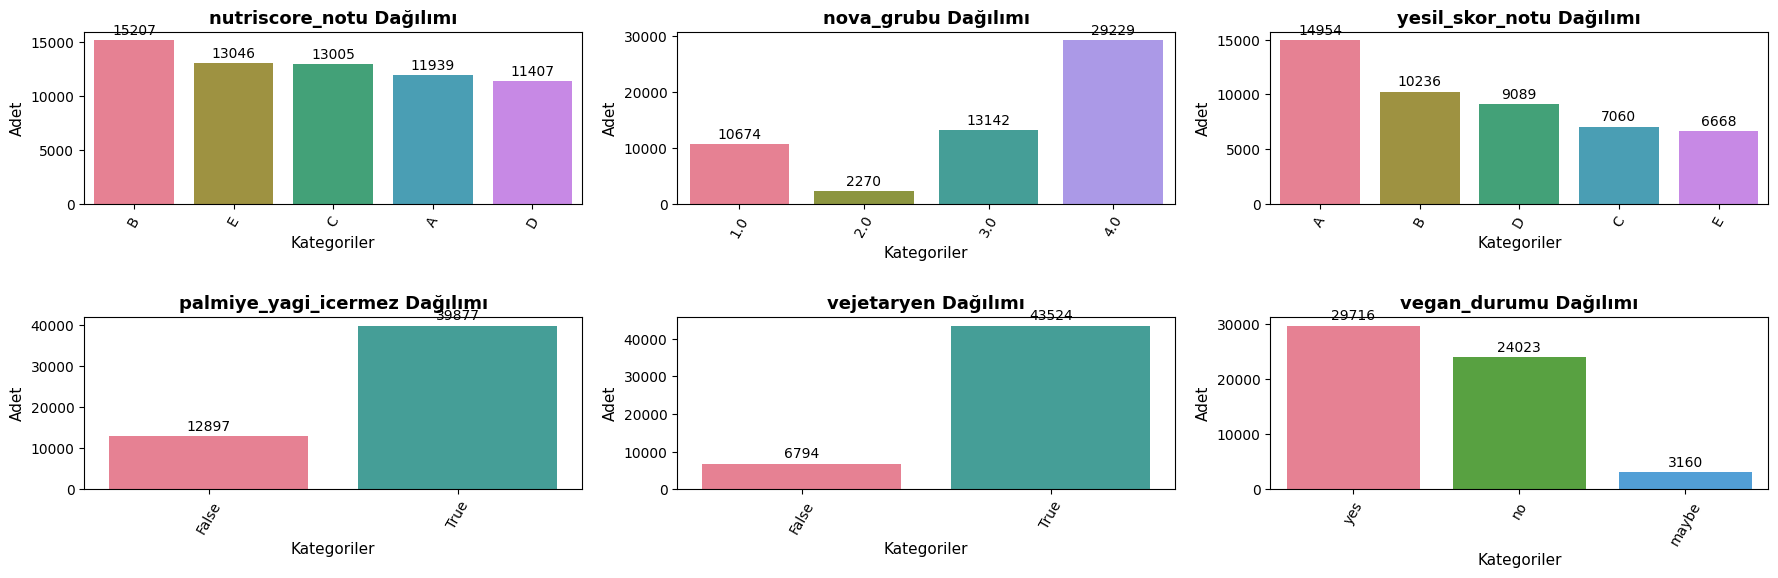

In [ ]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()


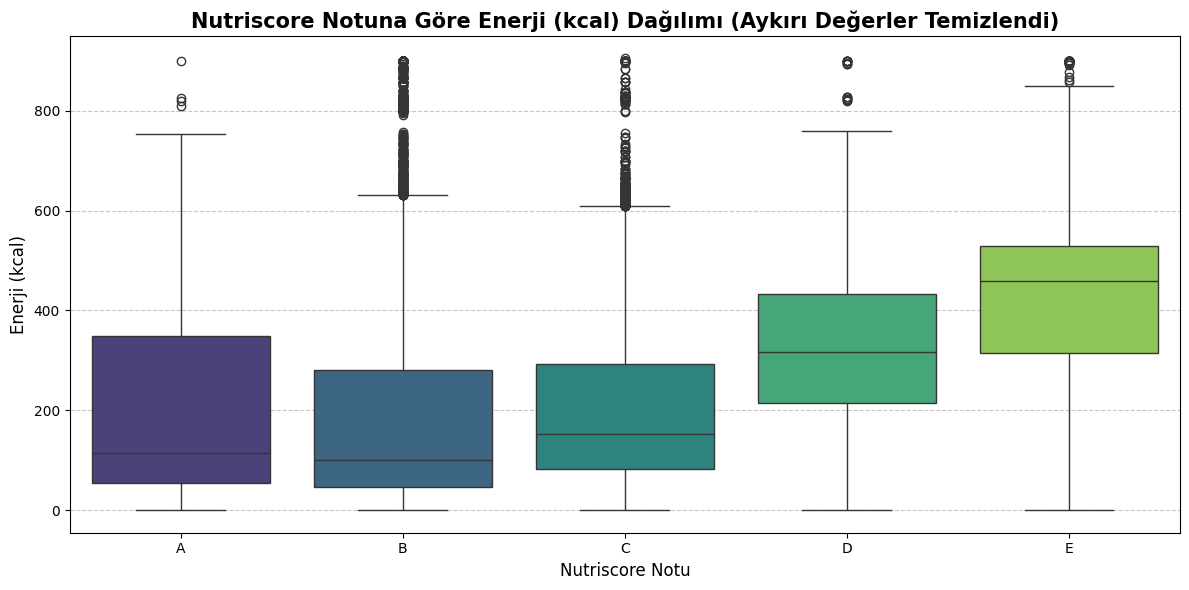

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlayalım
df_plot = data[['enerji_kcal', 'nutriscore_notu']].dropna()

# --- UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ) ---
Q1 = df_plot['enerji_kcal'].quantile(0.25)
Q3 = df_plot['enerji_kcal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sınırlar dışında kalan verileri temizleyelim
df_filtered = df_plot[(df_plot['enerji_kcal'] >= lower_bound) & (df_plot['enerji_kcal'] <= upper_bound)]
# ---------------------------------------------

# Nutriscore notlarını sıralı bir şekilde göstermek için liste tanımlayalım
nutriscore_order = ['A', 'B', 'C', 'D', 'E']

# Eğer veri setinizde bazı harfler yoksa mevcut olanları filtreleyelim
existing_scores = [score for score in nutriscore_order if score in df_filtered['nutriscore_notu'].unique()]

plt.figure(figsize=(12, 6))

# Boxplot çizimi (Temizlenmiş veri ile)
sns.boxplot(
    x='nutriscore_notu', 
    y='enerji_kcal', 
    data=df_filtered, 
    order=existing_scores, 
    palette='viridis'
)

# Grafik detayları
plt.title('Nutriscore Notuna Göre Enerji (kcal) Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Nutriscore Notu', fontsize=12)
plt.ylabel('Enerji (kcal)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafiği gösterme
plt.tight_layout()
plt.show()